# Credit Card Default Prediction

**Statistical Learning Project — University of Haifa**  
**Andrey Makushev & Itay Pizanty**

## Project Overview
This project aims to predict credit card default using financial and demographic customer data.

## Features
- **X1**: Credit Limit
- **X2**: Gender (Categorical)
- **X3**: Education Level (Categorical)
- **X4**: Marital Status (Categorical)
- **X5**: Age
- **X6-X11**: Payment History for the last six months
- **X12-X17**: Bill Amounts for the last six months
- **X18-X23**: Previous Payments for the last six months
- **Debt_Ratio**: Derived feature (X12 / X1)
- **Avg_Payment**: Derived feature (mean of X18-X23)

## Target Variable
- **default**: 1 if the customer defaulted, 0 otherwise.


# Imports
This notebook requires `tensorflow`, `ucimlrepo`, `scikeras`, and `xgboost` in addition to the standard data-science packages used below.


In [41]:
import os
import time

# Suppress TensorFlow informational messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from xgboost import XGBClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as LDA,
    QuadraticDiscriminantAnalysis as QDA,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential


# Data Loading and Cleaning
Loaded the dataset, standardized column names, checked for missing values, removed duplicate rows, and removed the non-informative ID column.


In [8]:
# Load dataset
dataset = fetch_ucirepo(id=350)
data = dataset.data.original.copy()

# Standardize column names and rename the target variable
data.columns = data.columns.str.strip()
if 'Y' in data.columns:
    data.rename(columns={'Y': 'default'}, inplace=True)

# Drop the non-informative ID column if present
if 'ID' in data.columns:
    data.drop(columns=['ID'], inplace=True)

# Check missing values and remove duplicate rows
print("Missing values per column:\n", data.isnull().sum())
data.drop_duplicates(inplace=True)

# Display dataset information and the first rows
print("\nDataset Overview:")
data.info()
print("\nFirst 5 rows of dataset:")
print(data.head())


Missing values per column:
 X1         0
X2         0
X3         0
X4         0
X5         0
X6         0
X7         0
X8         0
X9         0
X10        0
X11        0
X12        0
X13        0
X14        0
X15        0
X16        0
X17        0
X18        0
X19        0
X20        0
X21        0
X22        0
X23        0
default    0
dtype: int64

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   X1       29965 non-null  int64
 1   X2       29965 non-null  int64
 2   X3       29965 non-null  int64
 3   X4       29965 non-null  int64
 4   X5       29965 non-null  int64
 5   X6       29965 non-null  int64
 6   X7       29965 non-null  int64
 7   X8       29965 non-null  int64
 8   X9       29965 non-null  int64
 9   X10      29965 non-null  int64
 10  X11      29965 non-null  int64
 11  X12      29965 non-null  int64
 12  X13      29965 

# Exploratory Data Analysis (EDA)
- **Target Variable Distribution**: Visualizes the class imbalance in the dataset.
- **Feature Correlation Heatmap**: Shows relationships between numerical features.
- **Feature Distributions**: Histograms to analyze the spread of key features.
- **Boxplots of Financial Features**: Identifies outliers and data ranges in key financial variables.


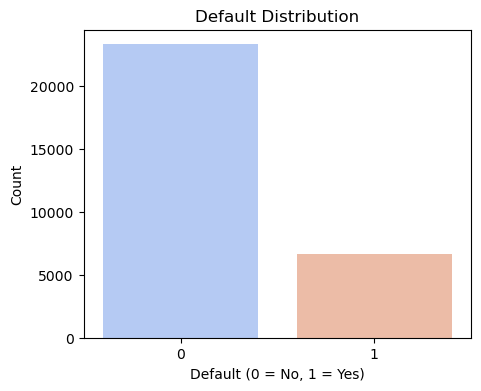

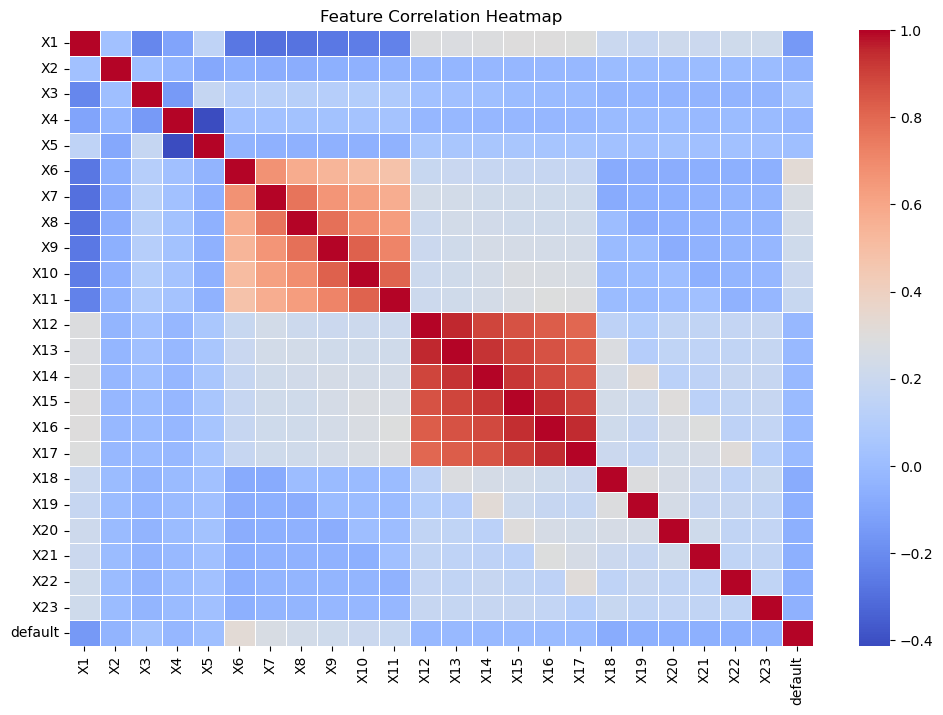

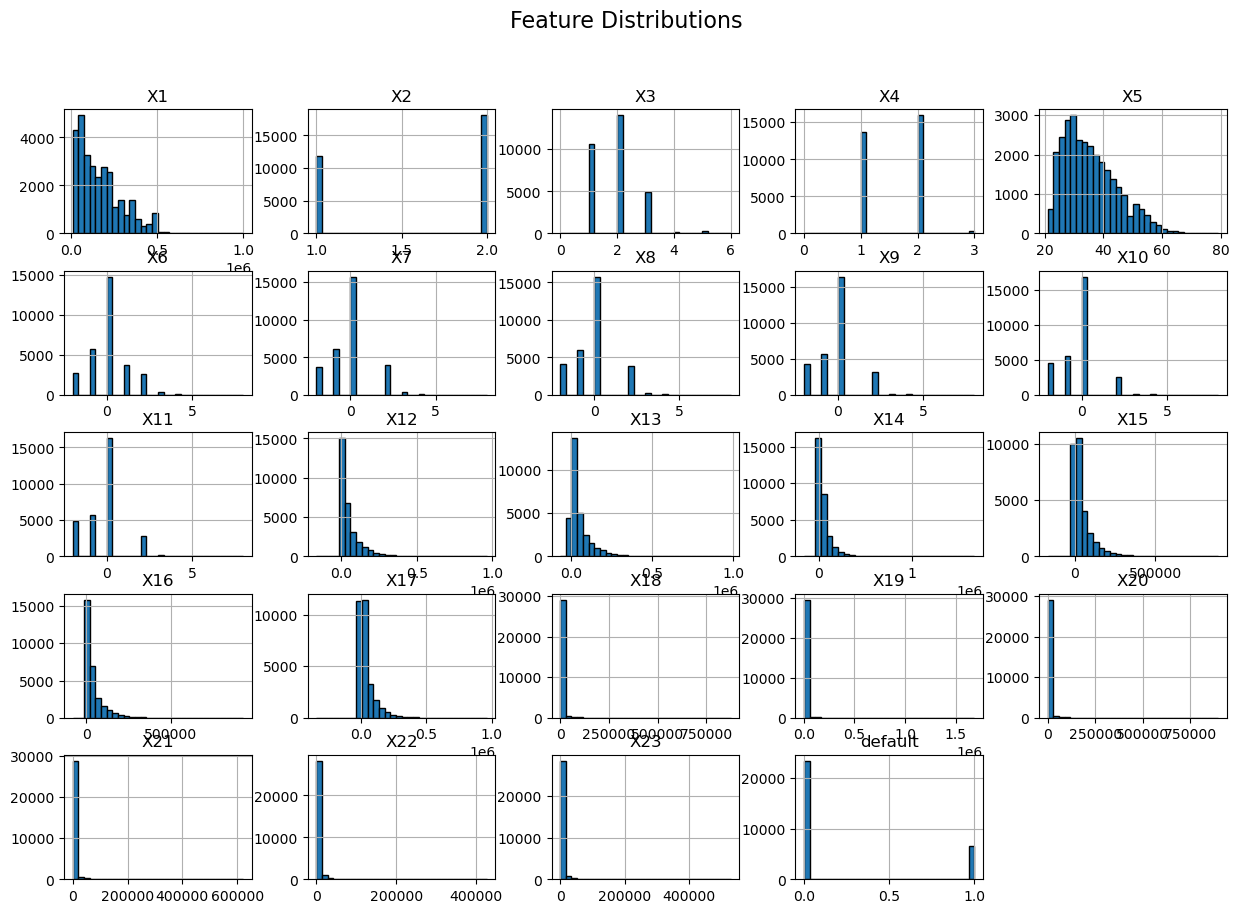

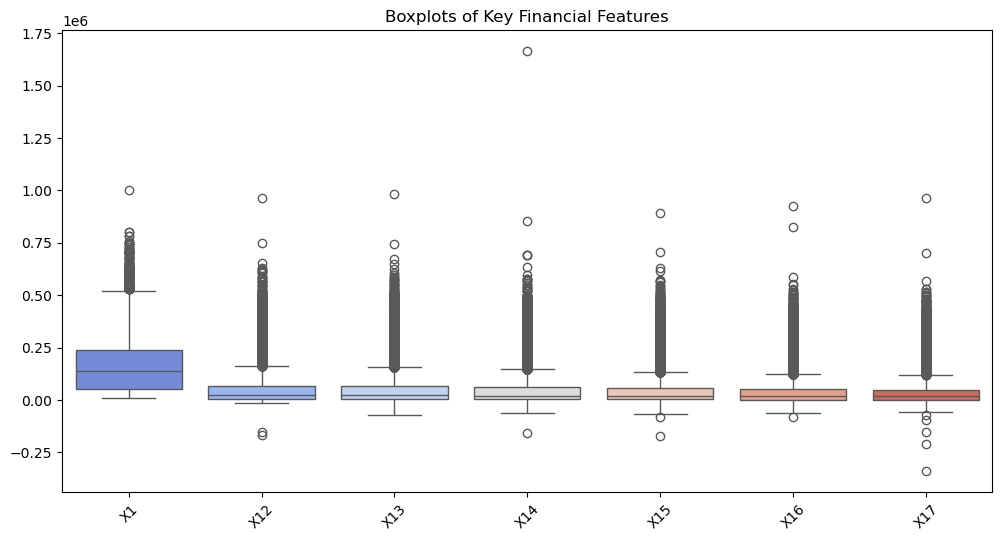

In [11]:
# EDA: Distribution of the target variable
plt.figure(figsize=(5,4))
sns.countplot(x='default', hue='default', data=data, palette="coolwarm", legend=False)
plt.title("Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# EDA: Heatmap of feature correlations
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# EDA: Histogram of features
data.hist(figsize=(15,10), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# EDA: Boxplots of selected financial features
plt.figure(figsize=(12,6))
sns.boxplot(data=data[['X1', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17']], palette="coolwarm")
plt.title("Boxplots of Key Financial Features")
plt.xticks(rotation=45)
plt.show()


# Feature Engineering and Preprocessing
- Created two derived features: `Debt_Ratio` and `Avg_Payment`.
- Encoded categorical variables.
- Standardized numerical features.


In [14]:
# New features: debt-to-credit ratio and average payment
data["Debt_Ratio"] = data["X12"] / data["X1"]
data["Avg_Payment"] = data[['X18', 'X19', 'X20', 'X21', 'X22', 'X23']].mean(axis=1)

# Encode categorical variables (Gender, Education, Marriage)
categorical_cols = ['X2', 'X3', 'X4']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  

# Scale numerical features
scaler = StandardScaler()
num_cols = ['X1', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 
            'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 
            'Debt_Ratio', 'Avg_Payment']
data[num_cols] = scaler.fit_transform(data[num_cols])

# Separate features and target
X = data.drop(columns=['default'])
y = data['default']

print("\nProcessed Data Overview:")
print(data.head())



Processed Data Overview:
         X1  X2  X3  X4        X5        X6        X7        X8        X9  \
0 -1.136285   1   2   1 -1.246078  1.795105  1.782037 -0.698752 -0.668642   
1 -0.365619   1   2   2 -1.029141 -0.875185  1.782037  0.137468  0.187408   
2 -0.596819   1   2   2 -0.161397  0.014912  0.110218  0.137468  0.187408   
3 -0.905085   1   2   1  0.164007  0.014912  0.110218  0.137468  0.187408   
4 -0.905085   0   2   1  2.333368 -0.875185  0.110218 -0.698752  0.187408   

        X10  ...       X17       X18       X19       X20       X21       X22  \
0 -1.532847  ... -0.653264 -0.342158 -0.227257 -0.296984 -0.308253 -0.314331   
1  0.233623  ... -0.598525 -0.342158 -0.213767 -0.240218 -0.244454 -0.314331   
2  0.233623  ... -0.392257 -0.250556 -0.192078 -0.240218 -0.244454 -0.248912   
3  0.233623  ... -0.157286 -0.221470 -0.169565 -0.228864 -0.238074 -0.244398   
4  0.233623  ... -0.332130 -0.221470  1.334009  0.270680  0.265939 -0.269257   

        X23  default  Debt_Rat

# Train-Test Split & K-Fold Cross-Validation Setup
The data is split into stratified training and test sets (80/20), followed by shuffled 5-fold cross-validation for model tuning and evaluation.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("\nData Split Overview:")
print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")



Data Split Overview:
Training Set: 23972 samples
Test Set: 5993 samples


# Model Training and Hyperparameter Tuning

- **Models**: Logistic Regression, Random Forest, SVM, XGBoost, KNN, MLP, LDA, QDA, and DNN.
- **Hyperparameter Tuning**:
  - **GridSearchCV**: Logistic Regression, Random Forest, XGBoost, KNN, MLP, and DNN.
  - **RandomizedSearchCV**: SVM, used to reduce tuning time.
  - **DNN**: Tuned through SciKeras with TensorFlow/Keras.
  - **LDA and QDA**: Evaluated without hyperparameter tuning.
- **Evaluation**: Accuracy, precision, recall, F1-score, ROC-AUC, and training time.
- **Diagnostics**: Train/test comparisons, cross-validation scores, and learning curves for selected models.



Training DNN...
Best parameters for DNN: {'batch_size': 32, 'epochs': 100, 'model__activation': 'tanh', 'model__dropout_rate': 0.2, 'model__hidden_layers': (64,), 'model__optimizer': 'adam'}
DNN Training Time: 840.17 seconds

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Logistic Regression Training Time: 1.62 seconds

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 500}
Random Forest Training Time: 40.74 seconds

Training SVM...
Best parameters for SVM: {'kernel': 'rbf', 'gamma': 'auto', 'C': 0.01}
SVM Training Time: 339.38 seconds

Training XGBoost...


Best parameters for XGBoost: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 500, 'reg_alpha': 1, 'reg_lambda': 5, 'subsample': 0.7}
XGBoost Training Time: 125.32 seconds

Training KNN...
Best parameters for KNN: {'n_neighbors': 21, 'p': 1, 'weights': 'uniform'}
KNN Training Time: 9.04 seconds

Training MLP...
Best parameters for MLP: {'activation': 'relu', 'alpha': 1e-05, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'max_iter': 2000, 'momentum': 0.9, 'solver': 'sgd'}
MLP Training Time: 297.69 seconds

Training LDA...
LDA Training Time: 0.02 seconds

Training QDA...
QDA Training Time: 0.01 seconds



DNN Performance:
Accuracy: 0.8173, Precision: 0.6486, Recall: 0.3801, F1-Score: 0.4793, ROC-AUC: 0.7708

Logistic Regression Performance:
Accuracy: 0.8106, Precision: 0.7090, Recall: 0.2443, F1-Score: 0.3634, ROC-AUC: 0.7143

Random Forest Performance:
Accuracy: 0.8196, Precision: 0.6799, Recall: 0.3492, F1-Score: 0.4614, ROC-AUC: 0.7651

SVM Performance:
Accuracy: 0.8009, Precision: 0.6812, Recall: 0.1885, F1-Score: 0.2953, ROC-AUC: 0.7200

XGBoost Performance:
Accuracy: 0.8181, Precision: 0.6715, Recall: 0.3484, F1-Score: 0.4588, ROC-AUC: 0.7785

KNN Performance:
Accuracy: 0.8133, Precision: 0.6529, Recall: 0.3333, F1-Score: 0.4413, ROC-AUC: 0.7484

MLP Performance:
Accuracy: 0.8158, Precision: 0.6488, Recall: 0.3650, F1-Score: 0.4672, ROC-AUC: 0.7643

LDA Performance:
Accuracy: 0.8116, Precision: 0.6974, Recall: 0.2624, F1-Score: 0.3814, ROC-AUC: 0.7072

QDA Performance:
Accuracy: 0.7027, Precision: 0.3928, Recall: 0.6297, F1-Score: 0.4838, ROC-AUC: 0.7085


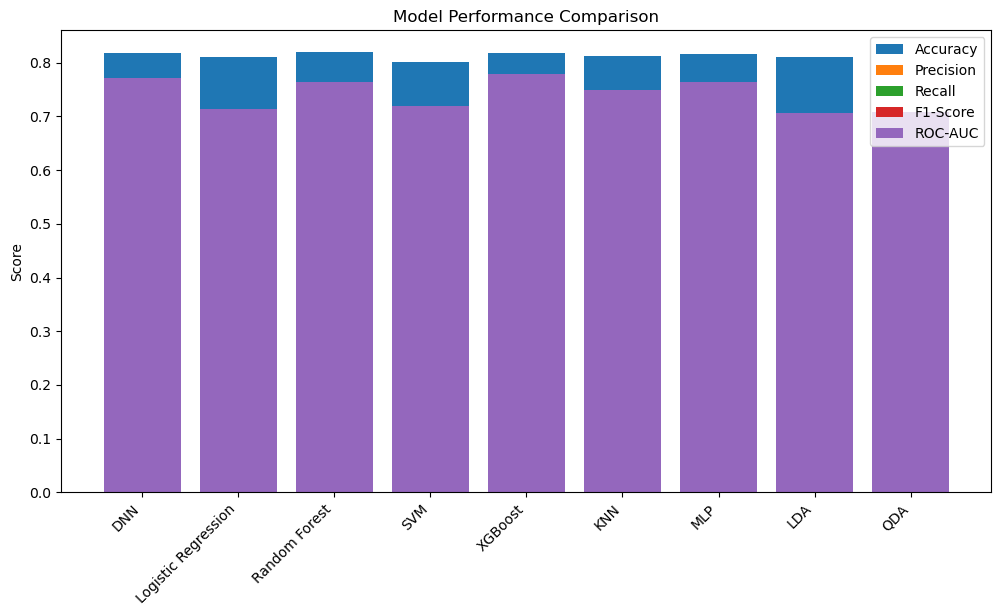

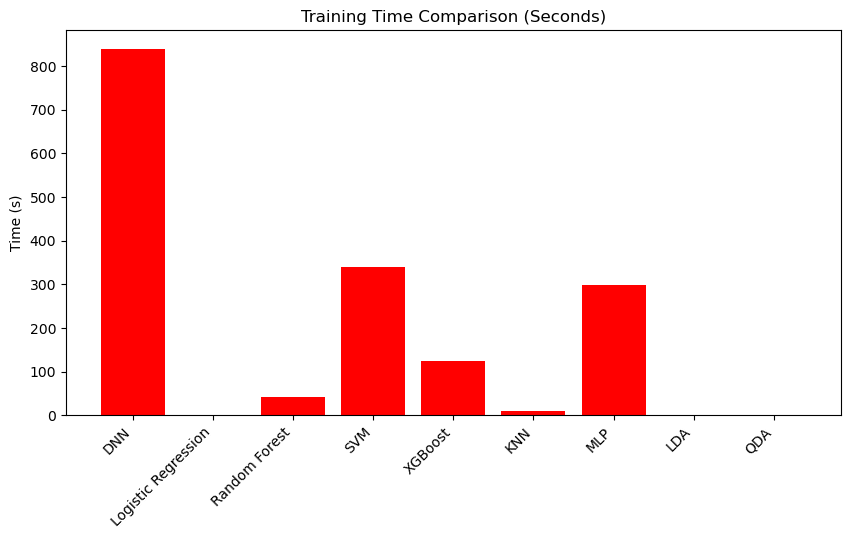

In [24]:
# Model Training & Hyperparameter Tuning

# Define a function to create the DNN model
def create_dnn_model(hidden_layers=(64,), activation='relu', dropout_rate=0.0, optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(hidden_layers[0], activation=activation))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['AUC'])
    return model
# Hyperparameter grids
param_grids = {
    "Logistic Regression": {
        "C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    },
    "Random Forest": {
        "n_estimators": [200, 500],
        "max_depth": [3, 5],
        "min_samples_split": [5, 10],
        "min_samples_leaf": [10, 15],
        "max_features": ["sqrt"]
    },
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "kernel": ["rbf"],
        "gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "n_estimators": [200, 500],
        "learning_rate": [ 0.01, 0.1],
        "max_depth": [3, 5, 7],
        "min_child_weight": [3, 5],
        "gamma": [0.1],
        "subsample": [0.7],
        "colsample_bytree": [0.7],
        "reg_alpha": [0, 0.01, 0.1, 1],
        "reg_lambda": [1, 2, 5]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 15, 21],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },
    "MLP": {
        "hidden_layer_sizes": [(64,), (128,), (64, 32)],
        "activation": ["relu", "tanh"],
        "solver": ["adam", "sgd"],
        "alpha": [0.00001, 0.0001, 0.001],
        "learning_rate": ["adaptive"],
        "momentum": [0.9],
        "max_iter": [2000]
    },
    "DNN": {
        "model__hidden_layers": [(64,)],
        "model__activation": ["tanh", "relu"],
        "model__dropout_rate": [0.0, 0.2, 0.5],
        "model__optimizer": ["adam", "sgd"],
        "batch_size": [16, 32],
        "epochs": [100]
        }
}

# Initialization
models = {
    "DNN": KerasClassifier(model=create_dnn_model, verbose=0),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(),
    "KNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(),
    "LDA": LDA(),
    "QDA": QDA()
}

# Train
best_models = {}
training_times = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    
    if name in param_grids:
        # Use RandomizedSearchCV for SVM to speed up tuning
        if name == "SVM":
            grid_search = RandomizedSearchCV(
                model, param_grids[name], cv=kf, scoring='roc_auc',
                n_iter=5, n_jobs=-1, random_state=42
            )
        else:
            grid_search = GridSearchCV(
                model, param_grids[name], cv=kf, scoring='roc_auc', n_jobs=-1
            )
        grid_search.fit(X_train, y_train)
        best_models[name] = grid_search.best_estimator_
        print(f"Best parameters for {name}: {grid_search.best_params_}")
    else:
        model.fit(X_train, y_train)
        best_models[name] = model

    training_times[name] = round(time.time() - start_time, 2)
    print(f"{name} Training Time: {training_times[name]} seconds")

# Evaluate models on the test set
model_results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    model_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    }
    
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, "
          f"F1-Score: {f1:.4f}, ROC-AUC: {auc:.4f}")

# Visualize overall model performance
plt.figure(figsize=(12,6))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
for metric in metrics:
    plt.bar(model_results.keys(), [model_results[m][metric] for m in model_results.keys()], label=metric)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(training_times.keys(), training_times.values(), color='red')
plt.xticks(rotation=45, ha='right')
plt.title("Training Time Comparison (Seconds)")
plt.ylabel("Time (s)")
plt.show()


# Bias-Variance Tradeoff and Overfitting Detection
- Compared training and test performance.
- Used cross-validation to assess variability across folds.
- Generated learning curves for selected models.

### Results
- Train/test gaps varied across models, with larger ROC-AUC gaps visible for models such as XGBoost, KNN, DNN, and MLP.
- Logistic Regression, Random Forest, SVM, LDA, and QDA showed smaller train/test gaps in the reported results.
- PCA, clustering, and permutation feature importance were then evaluated as additional transformations or feature-selection approaches.



Overfitting Check (Train vs. Test Performance):

DNN Overfitting Check:
Train Accuracy: 0.8268, Test Accuracy: 0.8173
Train ROC-AUC: 0.8025, Test ROC-AUC: 0.7708

Logistic Regression Overfitting Check:
Train Accuracy: 0.8090, Test Accuracy: 0.8106
Train ROC-AUC: 0.7275, Test ROC-AUC: 0.7143

Random Forest Overfitting Check:
Train Accuracy: 0.8245, Test Accuracy: 0.8196
Train ROC-AUC: 0.7878, Test ROC-AUC: 0.7651

SVM Overfitting Check:
Train Accuracy: 0.8017, Test Accuracy: 0.8009
Train ROC-AUC: 0.7368, Test ROC-AUC: 0.7200

XGBoost Overfitting Check:
Train Accuracy: 0.8294, Test Accuracy: 0.8181
Train ROC-AUC: 0.8157, Test ROC-AUC: 0.7785

KNN Overfitting Check:
Train Accuracy: 0.8202, Test Accuracy: 0.8133
Train ROC-AUC: 0.8146, Test ROC-AUC: 0.7484

MLP Overfitting Check:
Train Accuracy: 0.8237, Test Accuracy: 0.8158
Train ROC-AUC: 0.7968, Test ROC-AUC: 0.7643

LDA Overfitting Check:
Train Accuracy: 0.8105, Test Accuracy: 0.8116
Train ROC-AUC: 0.7207, Test ROC-AUC: 0.7072

QDA Over

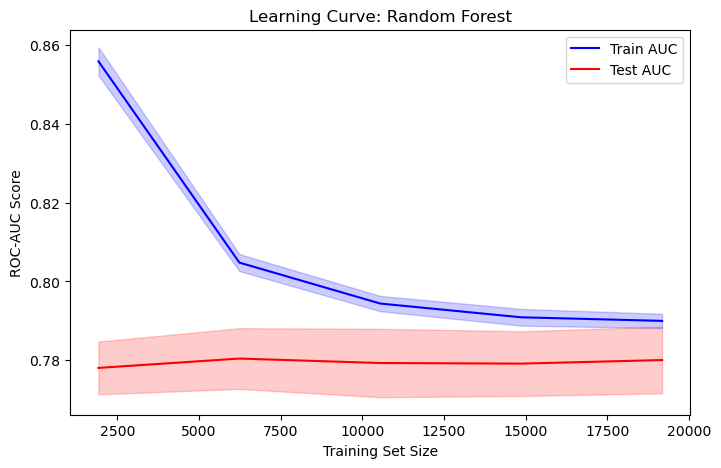

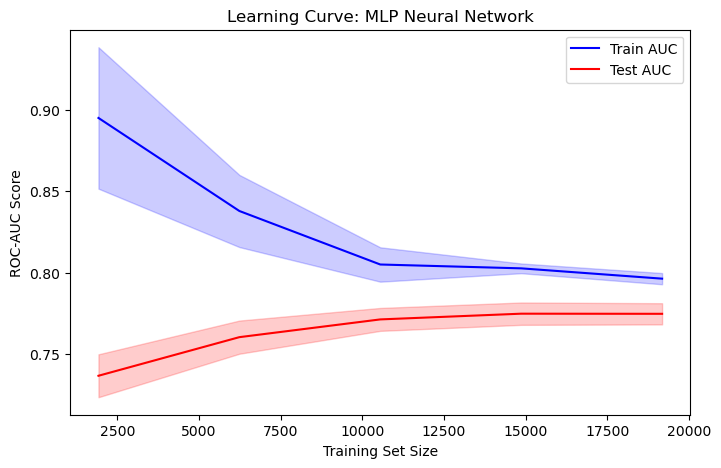

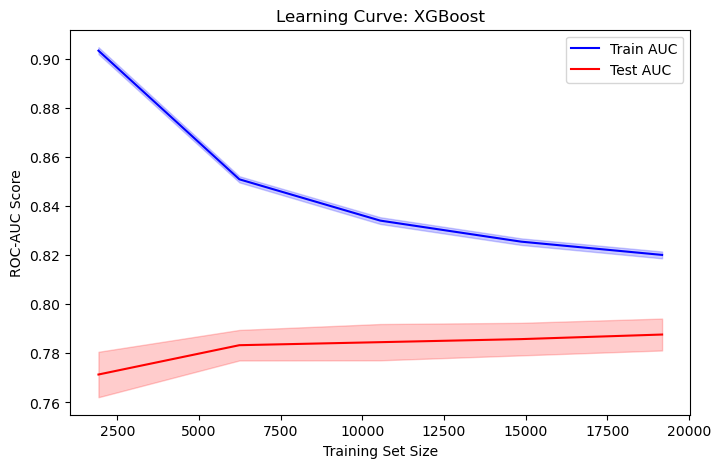

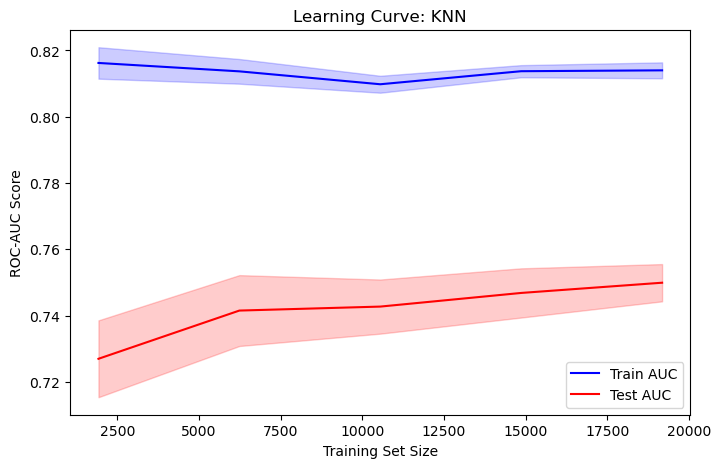

In [27]:
# Comparison of  train vs. test performance to assess overfitting
print("\nOverfitting Check (Train vs. Test Performance):")
for name, model in best_models.items():
    train_pred = model.predict(X_train)
    train_proba = model.predict_proba(X_train)[:, 1] if hasattr(model, "predict_proba") else None

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = model_results[name]["Accuracy"]

    train_auc = roc_auc_score(y_train, train_proba) if train_proba is not None else None
    test_auc = model_results[name]["ROC-AUC"]

    print(f"\n{name} Overfitting Check:")
    print(f"Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
    if train_auc is not None and test_auc is not None:
        print(f"Train ROC-AUC: {train_auc:.4f}, Test ROC-AUC: {test_auc:.4f}")

# Assess bias-variance tradeoff using cross-validation scores
print("\nBias-Variance Tradeoff (CV Scores):")
cv_results = {}
for name, model in best_models.items():
    if name in ["LDA", "QDA"]:
        continue
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='roc_auc')
    cv_results[name] = {"Mean AUC": np.mean(cv_scores), "Std AUC": np.std(cv_scores)}
    print(f"\n{name} CV Scores:")
    print(f"Mean AUC: {cv_results[name]['Mean AUC']:.4f}, Std Dev: {cv_results[name]['Std AUC']:.4f}")

# learning curves for selected models
def plot_learning_curve(model, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=kf, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, label="Train AUC", color="blue")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)
    plt.plot(train_sizes, test_mean, label="Test AUC", color="red")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="red", alpha=0.2)
    plt.title(f"Learning Curve: {title}")
    plt.xlabel("Training Set Size")
    plt.ylabel("ROC-AUC Score")
    plt.legend()
    plt.show()

print("\nGenerating Learning Curves for Selected Models...")
if "Random Forest" in best_models:
    plot_learning_curve(best_models["Random Forest"], "Random Forest")
if "MLP" in best_models:
    plot_learning_curve(best_models["MLP"], "MLP Neural Network")
if "XGBoost" in best_models:
    plot_learning_curve(best_models["XGBoost"], "XGBoost")
if "KNN" in best_models:
    plot_learning_curve(best_models["KNN"], "KNN")


### PCA Transformation with SVM & QDA
- Applied PCA to retain 95% of the variance.
- Trained and compared SVM and QDA before and after PCA.
- PCA had mixed effects: SVM recall and F1-score increased with nearly unchanged ROC-AUC, while QDA recall and ROC-AUC increased as accuracy and precision decreased.



Training SVM (PCA)...
SVM (PCA) Performance:
Accuracy: 0.8175, Precision: 0.6671, Recall: 0.3492, F1-Score: 0.4584, ROC-AUC: 0.7206

Training QDA (PCA)...
QDA (PCA) Performance:
Accuracy: 0.5735, Precision: 0.3097, Recall: 0.7549, F1-Score: 0.4392, ROC-AUC: 0.7231

Original vs PCA-Transformed Models Comparison:

SVM vs. SVM (PCA):
Accuracy: 0.8009 → 0.8175
Precision: 0.6812 → 0.6671
Recall: 0.1885 → 0.3492
F1-Score: 0.2953 → 0.4584
ROC-AUC: 0.7200 → 0.7206

QDA vs. QDA (PCA):
Accuracy: 0.7027 → 0.5735
Precision: 0.3928 → 0.3097
Recall: 0.6297 → 0.7549
F1-Score: 0.4838 → 0.4392
ROC-AUC: 0.7085 → 0.7231


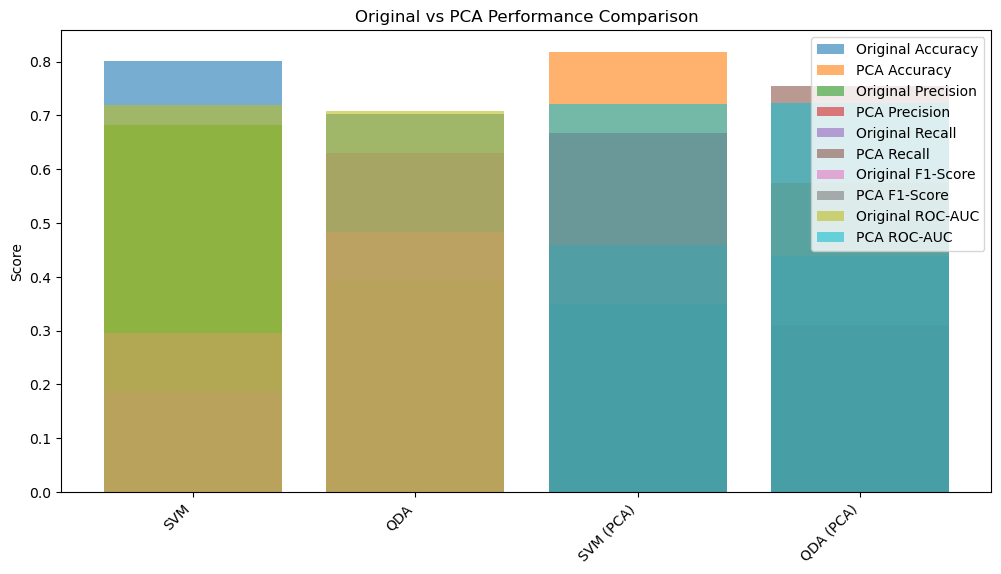

In [30]:
# PCA Transformation with SVM & QDA

# Apply PCA to retain 95% of variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train SVM and QDA on PCA-transformed data
pca_models = {
    "SVM (PCA)": SVC(kernel='rbf', C=1, probability=True),
    "QDA (PCA)": QDA()
}

pca_results = {}
for name, model in pca_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_pca, y_train)
    
    y_pred = model.predict(X_test_pca)
    y_proba = model.predict_proba(X_test_pca)[:, 1] if hasattr(model, "predict_proba") else None
    
    pca_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }
    
    print(f"{name} Performance:")
    print(f"Accuracy: {pca_results[name]['Accuracy']:.4f}, Precision: {pca_results[name]['Precision']:.4f}, "
          f"Recall: {pca_results[name]['Recall']:.4f}, F1-Score: {pca_results[name]['F1-Score']:.4f}, "
          f"ROC-AUC: {pca_results[name]['ROC-AUC']:.4f}")

# Comparison of  original SVM & QDA with  PCA
print("\nOriginal vs PCA-Transformed Models Comparison:")
for name in ["SVM", "QDA"]:
    print(f"\n{name} vs. {name} (PCA):")
    for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
        orig_value = model_results[name][metric]
        pca_value = pca_results[f"{name} (PCA)"][metric]
        print(f"{metric}: {orig_value:.4f} → {pca_value:.4f}")

# Visualization of  performance comparison between original and PCA models
plt.figure(figsize=(12,6))
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    plt.bar(["SVM", "QDA"],
            [model_results["SVM"][metric], model_results["QDA"][metric]],
            label=f"Original {metric}", alpha=0.6)
    plt.bar(["SVM (PCA)", "QDA (PCA)"],
            [pca_results["SVM (PCA)"][metric], pca_results["QDA (PCA)"][metric]],
            label=f"PCA {metric}", alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title("Original vs PCA Performance Comparison")
plt.ylabel("Score")
plt.show()


### Clustering + KNN, QDA, Logistic Regression
- Applied K-Means clustering to create an additional cluster feature.
- Retrained KNN, QDA, and Logistic Regression with the cluster labels included.
- Compared the original and clustering-enhanced variants.
- Results were mixed: Logistic Regression remained nearly unchanged, while KNN and QDA gained recall but weakened on several other metrics.



Finding Optimal Number of Clusters...


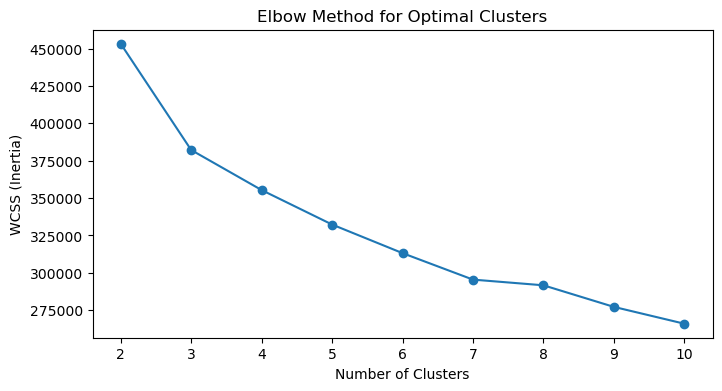

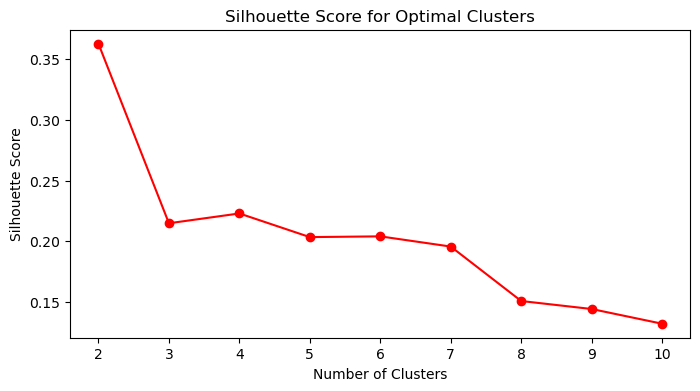


Optimal Number of Clusters: 2

Training KNN (Clustering) with clustered data...
KNN (Clustering) Performance:
Accuracy: 0.8063, Precision: 0.6119, Recall: 0.3401, F1-Score: 0.4372, ROC-AUC: 0.7297

Training QDA (Clustering) with clustered data...
QDA (Clustering) Performance:
Accuracy: 0.5690, Precision: 0.3063, Recall: 0.7496, F1-Score: 0.4349, ROC-AUC: 0.7029

Training Logistic Regression (Clustering) with clustered data...
Logistic Regression (Clustering) Performance:
Accuracy: 0.8109, Precision: 0.7112, Recall: 0.2451, F1-Score: 0.3646, ROC-AUC: 0.7144

Original vs Clustering Models Comparison:

KNN vs. KNN (Clustering):
Accuracy: 0.8133 → 0.8063
Precision: 0.6529 → 0.6119
Recall: 0.3333 → 0.3401
F1-Score: 0.4413 → 0.4372
ROC-AUC: 0.7484 → 0.7297

QDA vs. QDA (Clustering):
Accuracy: 0.7027 → 0.5690
Precision: 0.3928 → 0.3063
Recall: 0.6297 → 0.7496
F1-Score: 0.4838 → 0.4349
ROC-AUC: 0.7085 → 0.7029

Logistic Regression vs. Logistic Regression (Clustering):
Accuracy: 0.8106 → 0.810

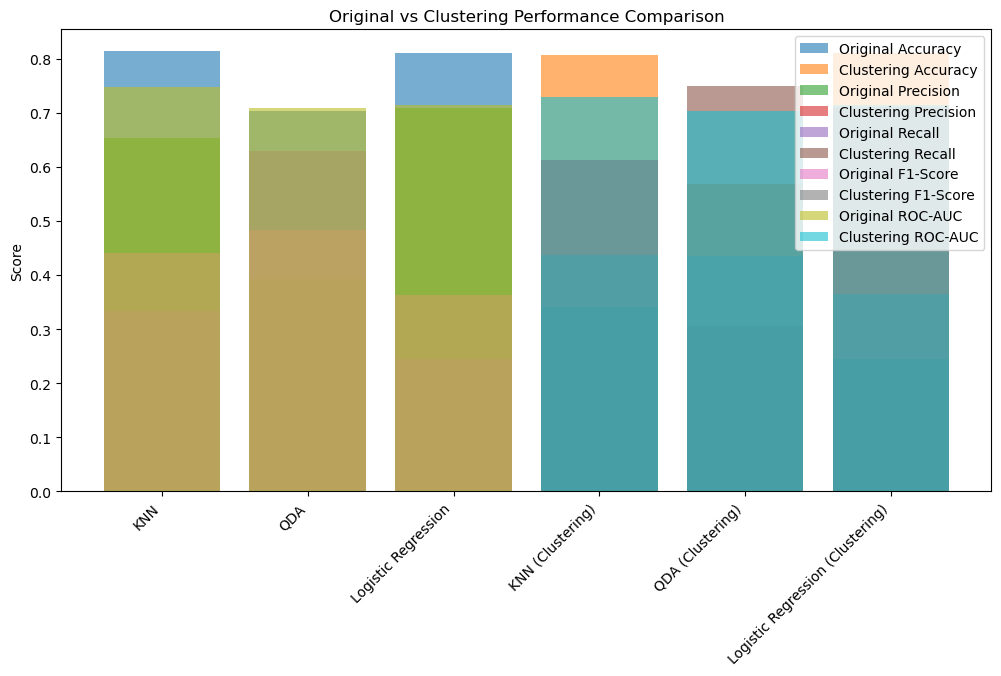

In [33]:
# K-Means Clustering for Enhanced Model Training

print("\nFinding Optimal Number of Clusters...")

wcss = []
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train, cluster_labels))

plt.figure(figsize=(8,4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(K_range, silhouette_scores, marker='o', color='red')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal Clusters')
plt.show()

optimal_clusters = np.argmax(silhouette_scores) + 2  # range starts at 2
print(f"\nOptimal Number of Clusters: {optimal_clusters}")

# Append cluster labels to the feature set
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
X_train_clustered = np.column_stack((X_train, kmeans.fit_predict(X_train)))
X_test_clustered = np.column_stack((X_test, kmeans.predict(X_test)))

# Train models on clustered data
cluster_models = {
    "KNN (Clustering)": KNeighborsClassifier(n_neighbors=9, weights='uniform'),
    "QDA (Clustering)": QDA(),
    "Logistic Regression (Clustering)": LogisticRegression(C=0.1, penalty='l2', solver='liblinear')
}

cluster_results = {}
for name, model in cluster_models.items():
    print(f"\nTraining {name} with clustered data...")
    model.fit(X_train_clustered, y_train)

    y_pred = model.predict(X_test_clustered)
    y_proba = model.predict_proba(X_test_clustered)[:, 1] if hasattr(model, "predict_proba") else None

    cluster_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

    print(f"{name} Performance:")
    print(f"Accuracy: {cluster_results[name]['Accuracy']:.4f}, Precision: {cluster_results[name]['Precision']:.4f}, "
          f"Recall: {cluster_results[name]['Recall']:.4f}, F1-Score: {cluster_results[name]['F1-Score']:.4f}, "
          f"ROC-AUC: {cluster_results[name]['ROC-AUC']:.4f}")

# Comparison of  original vs. clustering-enhanced models
print("\nOriginal vs Clustering Models Comparison:")
for name in ["KNN", "QDA", "Logistic Regression"]:
    print(f"\n{name} vs. {name} (Clustering):")
    for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
        orig_value = model_results[name][metric]
        cluster_value = cluster_results[f"{name} (Clustering)"][metric]
        print(f"{metric}: {orig_value:.4f} → {cluster_value:.4f}")

plt.figure(figsize=(12,6))
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    plt.bar(["KNN", "QDA", "Logistic Regression"],
            [model_results["KNN"][metric], model_results["QDA"][metric], model_results["Logistic Regression"][metric]],
            label=f"Original {metric}", alpha=0.6)
    plt.bar(["KNN (Clustering)", "QDA (Clustering)", "Logistic Regression (Clustering)"],
            [cluster_results["KNN (Clustering)"][metric],
             cluster_results["QDA (Clustering)"][metric],
             cluster_results["Logistic Regression (Clustering)"][metric]],
            label=f"Clustering {metric}", alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title("Original vs Clustering Performance Comparison")
plt.ylabel("Score")
plt.show()


### Permutation Feature Importance (PFI)
- Applied PFI to Random Forest, XGBoost, and KNN.
- Selected the top 70% of features by permutation importance for each model.
- Retrained the models using the reduced feature sets.
- The reduced-feature variants produced similar or slightly improved reported performance.



Computing Permutation Feature Importance...


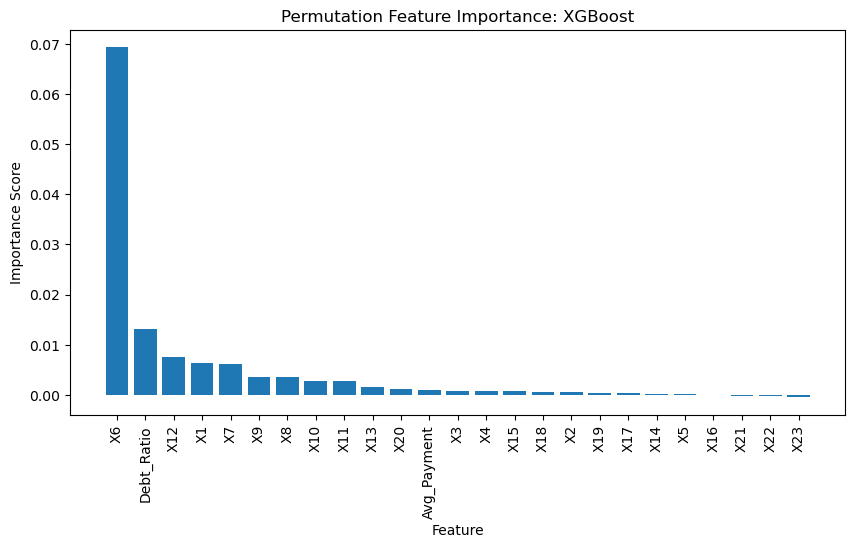

XGBoost: Feature importance computed.


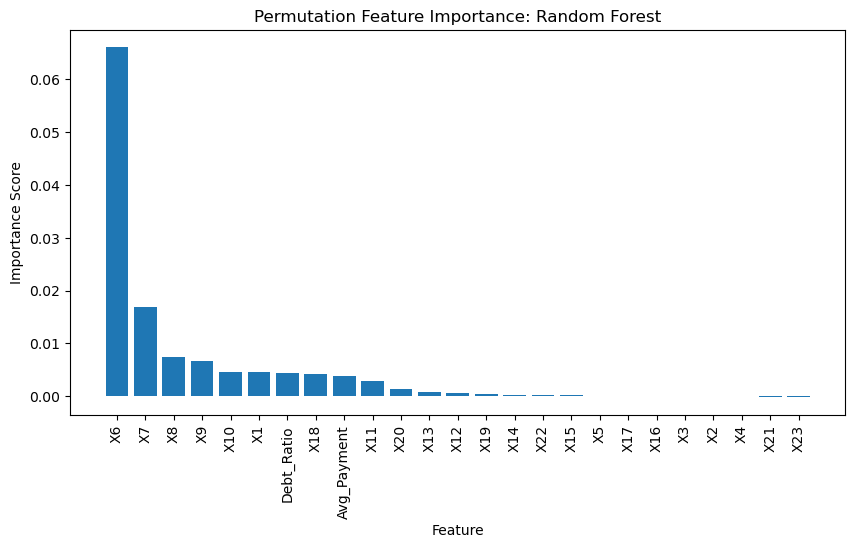

Random Forest: Feature importance computed.


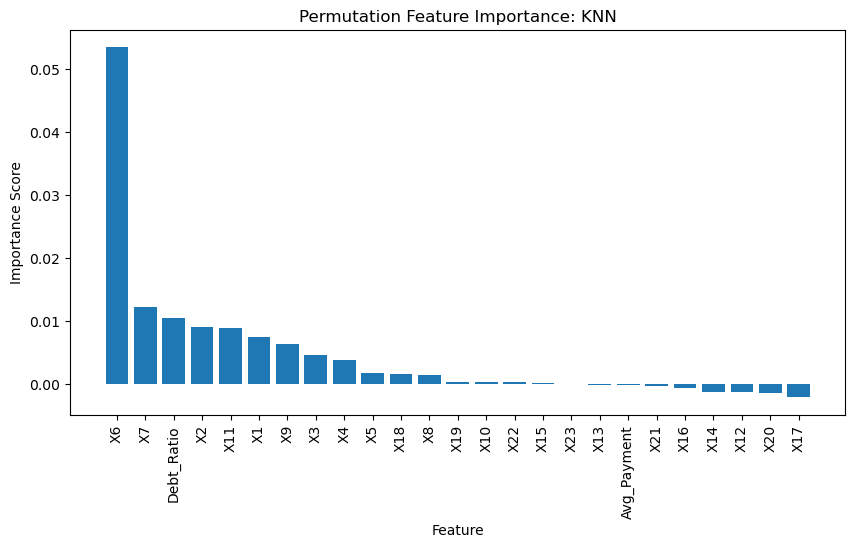

KNN: Feature importance computed.

Top features selected for each model.

Retraining Models with Selected Features...
XGBoost Performance after Feature Selection:
Accuracy: 0.8183, Precision: 0.6695, Recall: 0.3529, F1-Score: 0.4622, ROC-AUC: 0.7789
Random Forest Performance after Feature Selection:
Accuracy: 0.8203, Precision: 0.6828, Recall: 0.3507, F1-Score: 0.4634, ROC-AUC: 0.7667
KNN Performance after Feature Selection:
Accuracy: 0.8136, Precision: 0.6482, Recall: 0.3446, F1-Score: 0.4500, ROC-AUC: 0.7494

Model Comparison: Full Features vs Reduced Features

XGBoost Performance Change:
Accuracy: 0.8181 → 0.8183
Precision: 0.6715 → 0.6695
Recall: 0.3484 → 0.3529
F1-Score: 0.4588 → 0.4622
ROC-AUC: 0.7785 → 0.7789

Random Forest Performance Change:
Accuracy: 0.8196 → 0.8203
Precision: 0.6799 → 0.6828
Recall: 0.3492 → 0.3507
F1-Score: 0.4614 → 0.4634
ROC-AUC: 0.7651 → 0.7667

KNN Performance Change:
Accuracy: 0.8133 → 0.8136
Precision: 0.6529 → 0.6482
Recall: 0.3333 → 0.3446
F1-Score:

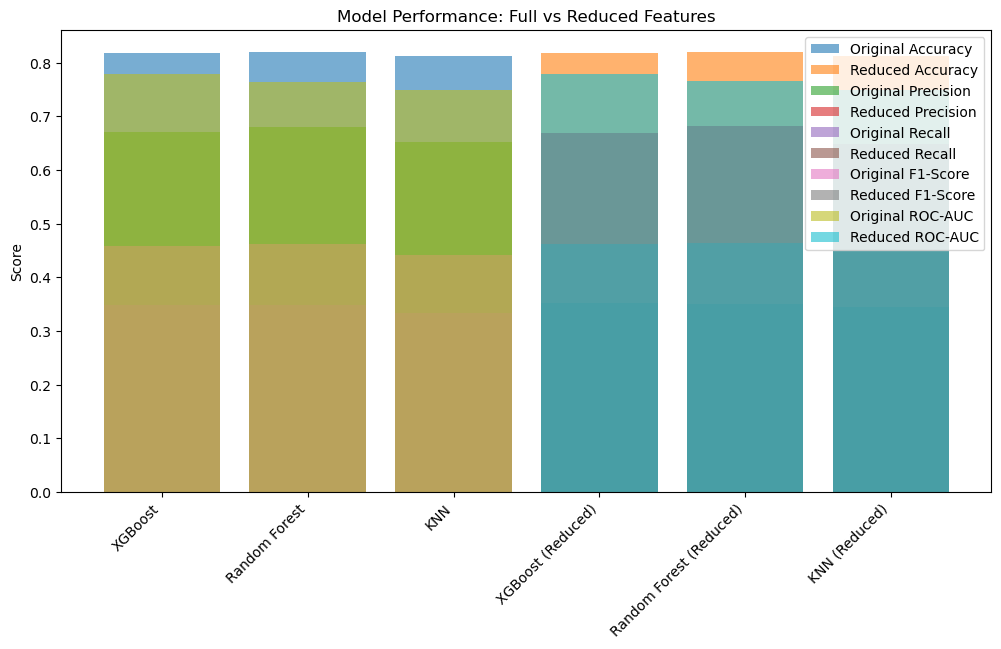

In [36]:
# Permutation Feature Importance and Feature Selection

models_to_test = ["XGBoost", "Random Forest", "KNN"]
feature_importance = {}

print("\nComputing Permutation Feature Importance...")
for model_name in models_to_test:
    model = best_models[model_name]
    result = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42, scoring="roc_auc"
    )
    feature_importance[model_name] = result.importances_mean
    sorted_idx = np.argsort(result.importances_mean)[::-1]

    plt.figure(figsize=(10, 5))
    plt.bar(range(X_test.shape[1]), result.importances_mean[sorted_idx], align="center")
    plt.xticks(range(X_test.shape[1]), X.columns[sorted_idx], rotation=90)
    plt.xlabel("Feature")
    plt.ylabel("Importance Score")
    plt.title(f"Permutation Feature Importance: {model_name}")
    plt.show()
    
    print(f"{model_name}: Feature importance computed.")

# Top 70% features based on importance for each model
top_features = {}
for model_name in models_to_test:
    sorted_idx = np.argsort(feature_importance[model_name])[::-1]
    top_features[model_name] = X.columns[sorted_idx][:int(0.7 * X.shape[1])].tolist()

print("\nTop features selected for each model.")

# Retrain models using only the selected features
reduced_feature_results = {}
print("\nRetraining Models with Selected Features...")
for model_name in models_to_test:
    selected_features = top_features[model_name]
    X_train_reduced = X_train[selected_features]
    X_test_reduced = X_test[selected_features]

    if model_name == "XGBoost":
        model = XGBClassifier(**best_models[model_name].get_params())
    elif model_name == "Random Forest":
        model = RandomForestClassifier(**best_models[model_name].get_params())
    elif model_name == "KNN":
        model = KNeighborsClassifier(**best_models[model_name].get_params())

    model.fit(X_train_reduced, y_train)
    y_pred = model.predict(X_test_reduced)
    y_proba = model.predict_proba(X_test_reduced)[:, 1] if hasattr(model, "predict_proba") else None

    reduced_feature_results[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

    print(f"{model_name} Performance after Feature Selection:")
    print(f"Accuracy: {reduced_feature_results[model_name]['Accuracy']:.4f}, Precision: {reduced_feature_results[model_name]['Precision']:.4f}, "
          f"Recall: {reduced_feature_results[model_name]['Recall']:.4f}, F1-Score: {reduced_feature_results[model_name]['F1-Score']:.4f}, "
          f"ROC-AUC: {reduced_feature_results[model_name]['ROC-AUC']:.4f}")

print("\nModel Comparison: Full Features vs Reduced Features")
for model_name in models_to_test:
    print(f"\n{model_name} Performance Change:")
    for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
        before = model_results[model_name][metric]
        after = reduced_feature_results[model_name][metric]
        print(f"{metric}: {before:.4f} → {after:.4f}")

plt.figure(figsize=(12,6))
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    plt.bar(models_to_test, [model_results[m][metric] for m in models_to_test],
            label=f"Original {metric}", alpha=0.6)
    plt.bar([f"{m} (Reduced)" for m in models_to_test],
            [reduced_feature_results[m][metric] for m in models_to_test],
            label=f"Reduced {metric}", alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title("Model Performance: Full vs Reduced Features")
plt.ylabel("Score")
plt.show()


# Final Model Comparison
Compared the baseline, PCA, clustering, and PFI variants using the same reported performance metrics.



Final Model Comparison Table:

                                  Accuracy  Precision    Recall  F1-Score  \
XGBoost (PFI)                     0.818288   0.669528  0.352941  0.462222   
XGBoost                           0.818121   0.671512  0.348416  0.458788   
DNN                               0.817287   0.648649  0.380090  0.479315   
Random Forest (PFI)               0.820290   0.682819  0.350679  0.463378   
Random Forest                     0.819623   0.679883  0.349170  0.461385   
MLP                               0.815785   0.648794  0.365008  0.467181   
KNN (PFI)                         0.813616   0.648227  0.344646  0.450025   
KNN                               0.813282   0.652880  0.333333  0.441338   
KNN (Clustering)                  0.806274   0.611940  0.340121  0.437227   
QDA (PCA)                         0.573502   0.309715  0.754902  0.439228   
SVM (PCA)                         0.817454   0.667147  0.349170  0.458416   
SVM                               0.800934  

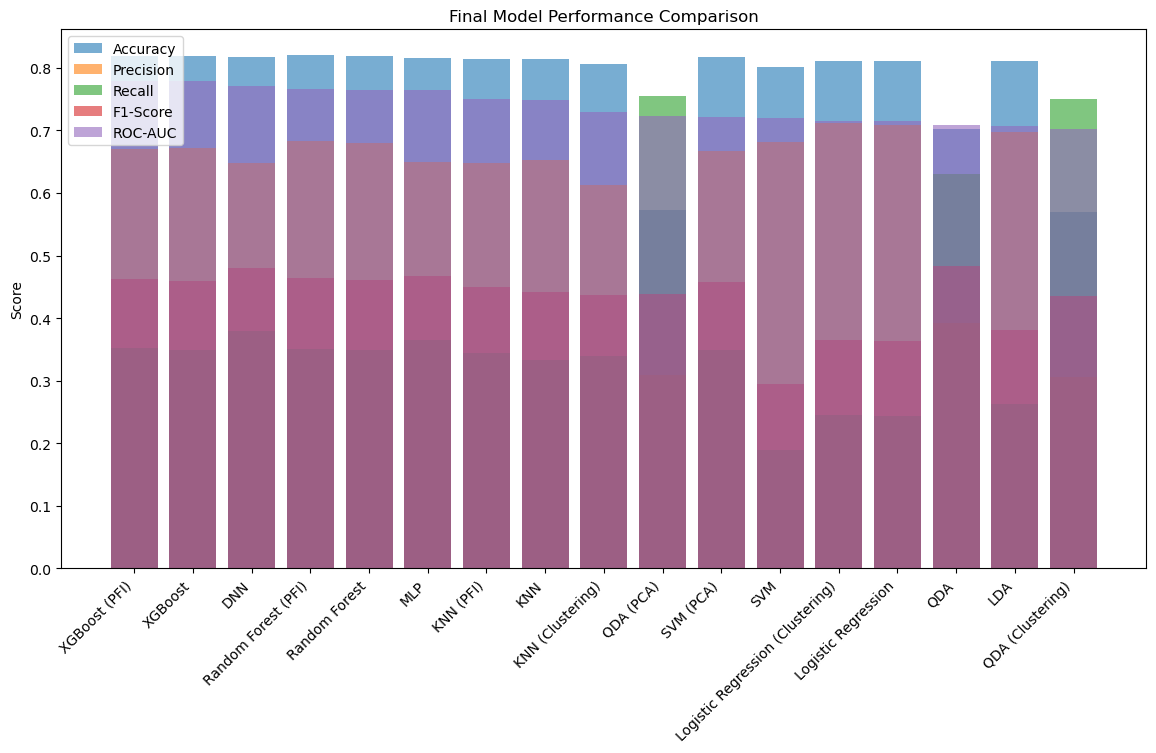

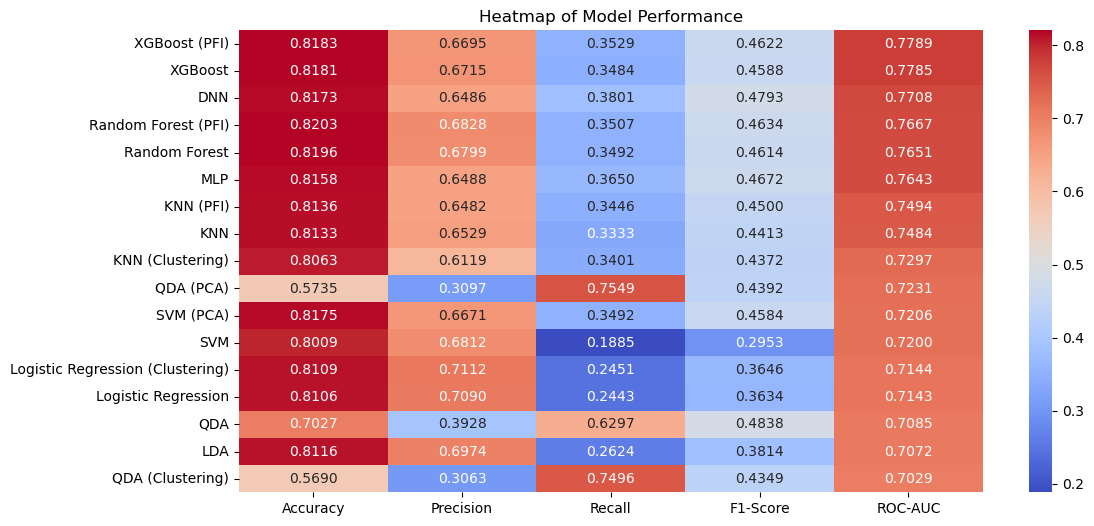


Best Model: XGBoost (PFI) with ROC-AUC: 0.7789


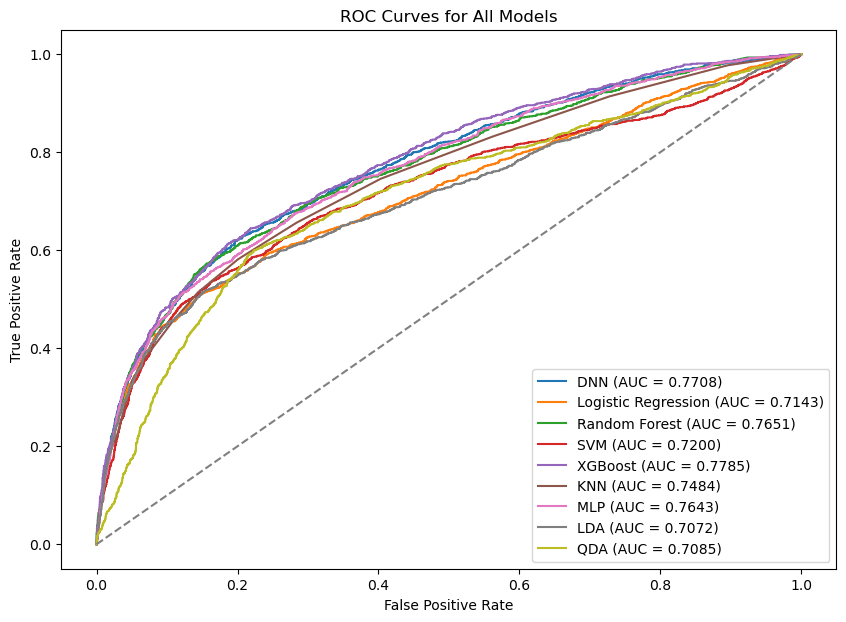

In [43]:
# All Model Results

all_models = {
    "Logistic Regression": model_results["Logistic Regression"],
    "LDA": model_results["LDA"],
    "QDA": model_results["QDA"],
    "Random Forest": model_results["Random Forest"],
    "XGBoost": model_results["XGBoost"],
    "MLP": model_results["MLP"],
    "SVM": model_results["SVM"],
    "KNN": model_results["KNN"],
    "SVM (PCA)": pca_results["SVM (PCA)"],
    "QDA (PCA)": pca_results["QDA (PCA)"],
    "KNN (Clustering)": cluster_results["KNN (Clustering)"],
    "QDA (Clustering)": cluster_results["QDA (Clustering)"],
    "Logistic Regression (Clustering)": cluster_results["Logistic Regression (Clustering)"],
    "Random Forest (PFI)": reduced_feature_results["Random Forest"],
    "XGBoost (PFI)": reduced_feature_results["XGBoost"],
    "KNN (PFI)": reduced_feature_results["KNN"],
    "DNN": model_results["DNN"]  
}

final_results_df = pd.DataFrame(all_models).T
final_results_df = final_results_df.sort_values(by="ROC-AUC", ascending=False)

print("\nFinal Model Comparison Table:\n")
print(final_results_df)

# Bar Chart: Model Performance Comparison
plt.figure(figsize=(14, 7))
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    plt.bar(final_results_df.index, final_results_df[metric], label=metric, alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.show()

# Heatmap: Model Performance
plt.figure(figsize=(12, 6))
sns.heatmap(final_results_df, annot=True, cmap="coolwarm", fmt=".4f")
plt.title("Heatmap of Model Performance")
plt.show()

# Best Model Selection
best_model = final_results_df.index[0]
print(f"\nBest Model: {best_model} with ROC-AUC: {final_results_df.loc[best_model, 'ROC-AUC']:.4f}")

# ROC-AUC Curves for All Models
plt.figure(figsize=(10, 7))

for name, model in best_models.items():
    if hasattr(model, "predict_proba"):  # Only models with probability predictions
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()



# Final Conclusion

- **Best Performing Model**: **XGBoost (PFI)** achieved the highest reported ROC-AUC score (**0.7789**) in the final comparison.
- **DNN vs. Traditional Models**: The DNN performed competitively, but required substantially more training time than XGBoost and Random Forest.
- **Feature Selection (PFI)**: The reduced-feature XGBoost, Random Forest, and KNN variants showed small improvements in several reported metrics.
- **Dimensionality Reduction (PCA)**: PCA produced mixed results. SVM recall and F1-score improved with nearly unchanged ROC-AUC, while QDA gained recall and ROC-AUC at the cost of lower accuracy and precision.
- **Clustering Effects**: Adding a K-Means cluster feature had little effect on Logistic Regression; KNN and QDA gained recall but declined on several other metrics.
